**IMPORTING LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

**Load the CSV File**

In [3]:
df = pd.read_csv("AI_SupplyChain_Dataset_1M.csv")

df.head()
df.shape
df.columns

Index(['Order_ID', 'Order_Date', 'Product', 'Region', 'Sales', 'Profit',
       'Order_Quantity', 'Inventory_Level', 'Lead_Time', 'Demand', 'Stockout'],
      dtype='object')

**Understanding the Dataset**

In [4]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   Order_ID         1000000 non-null  int64 
 1   Order_Date       1000000 non-null  object
 2   Product          1000000 non-null  object
 3   Region           1000000 non-null  object
 4   Sales            1000000 non-null  int64 
 5   Profit           1000000 non-null  int64 
 6   Order_Quantity   1000000 non-null  int64 
 7   Inventory_Level  1000000 non-null  int64 
 8   Lead_Time        1000000 non-null  int64 
 9   Demand           1000000 non-null  int64 
 10  Stockout         1000000 non-null  bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 77.2+ MB


np.int64(0)

**Convert Date Column**

In [5]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Quarter"] = df["Order_Date"].dt.quarter

**Cleaning Data**

In [6]:
df = df.drop_duplicates()

df["Stockout"] = df["Stockout"].astype(int)

df.isnull().sum()
df["Sales"] = df["Sales"].fillna(df["Sales"].median())
df["Profit"] = df["Profit"].fillna(df["Profit"].median())
df["Inventory_Level"] = df["Inventory_Level"].fillna(df["Inventory_Level"].median())
df["Lead_Time"] = df["Lead_Time"].fillna(df["Lead_Time"].median())

**Creating Useful KPI Columns**

In [7]:
df["Profit_Margin_%"] = (df["Profit"] / df["Sales"]) * 100

df["Demand_Gap"] = df["Demand"] - df["Order_Quantity"]

df["Inventory_Status"] = np.where(
    df["Inventory_Level"] < df["Demand"],
    "Low Inventory",
    "Healthy Inventory"
)

df["Lead_Time_Category"] = pd.cut(
    df["Lead_Time"],
    bins=[0, 5, 10, 15],
    labels=["Fast", "Medium", "Slow"]
)

**Exploratory Data Analysis**

Total Sales, Profit, Quantity

In [8]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Order_Quantity"].sum()
stockout_rate = df["Stockout"].mean() * 100

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Stockout Rate %:", stockout_rate)

Total Sales: 549711363
Total Profit: 154498058
Total Quantity: 10007314
Stockout Rate %: 0.0


**Sales by Region**

In [9]:
sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

sales_region

,Sales
Region,
US,137660255
Asia,137558395
Europe,137466307
Africa,137026406


In [21]:
print(sales_region.head(1))

Region
US    137660255
Name: Sales, dtype: int64


**Visualize the Sales by Region**

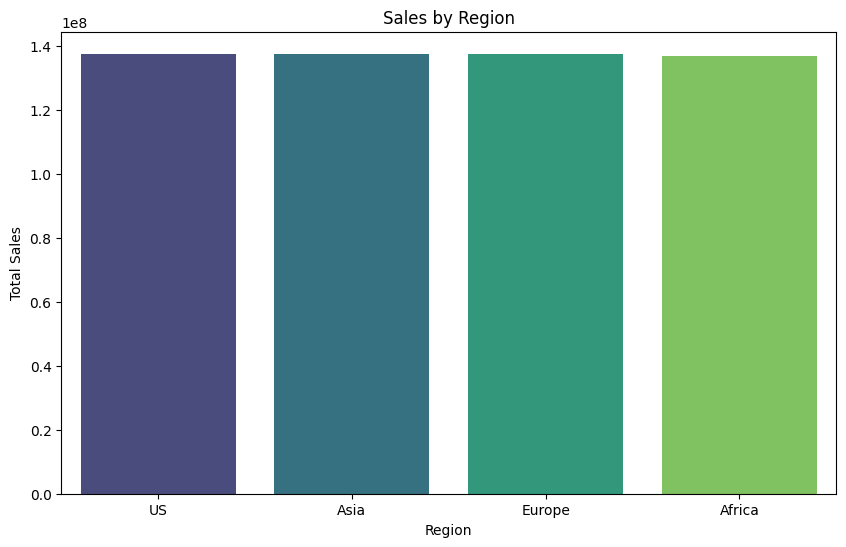

In [15]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_region.index, y=sales_region.values, hue=sales_region.index, palette='viridis', legend=False)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

**Profit by Product**

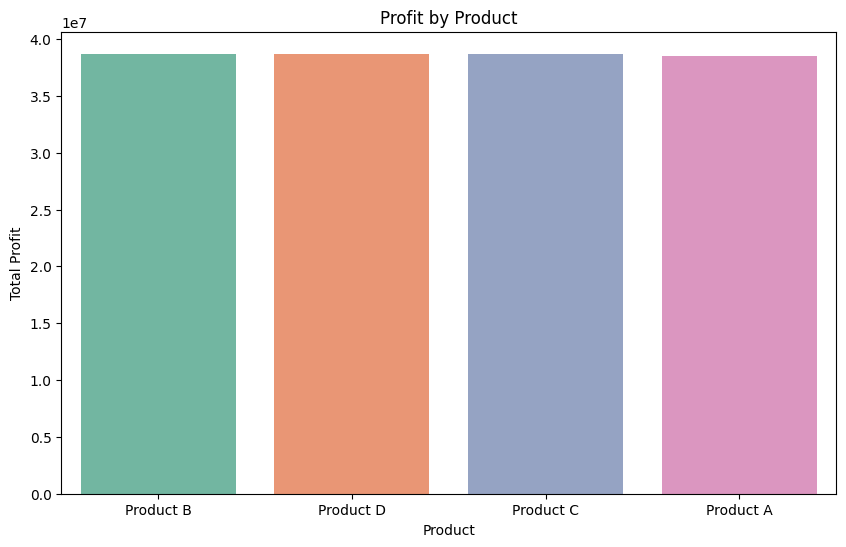

In [17]:
profit_product = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=profit_product.index, y=profit_product.values, hue=profit_product.index, palette='Set2', legend=False)
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.show()

**Monthly Sales Trend**

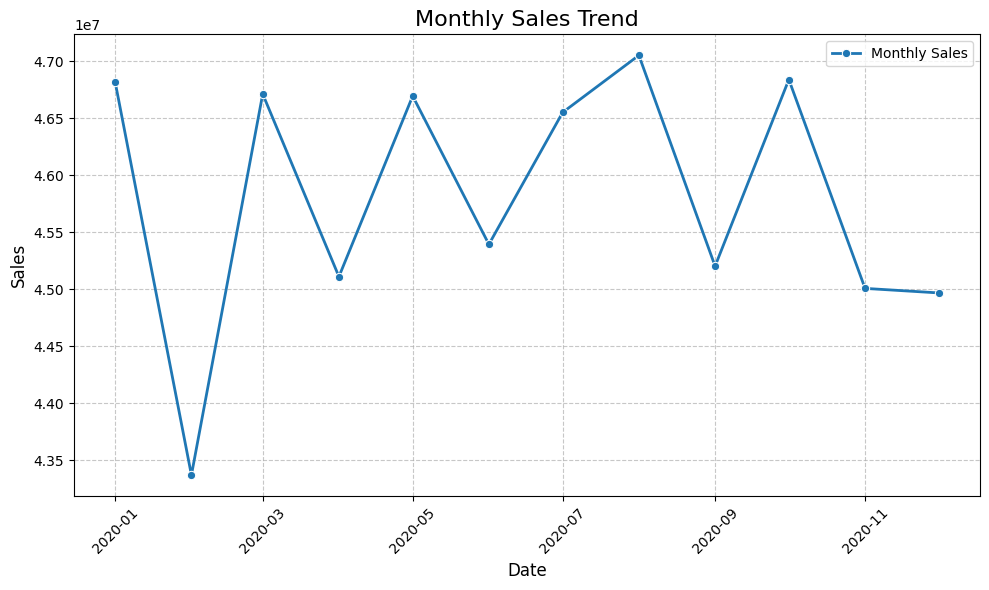

In [20]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str) + "-01"
)

# Use seaborn for a better chart with a legend
plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="Sales", data=monthly_sales, marker='o', linewidth=2, label='Monthly Sales') # Add markers, line width, and label for legend
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Stockout Analysis**

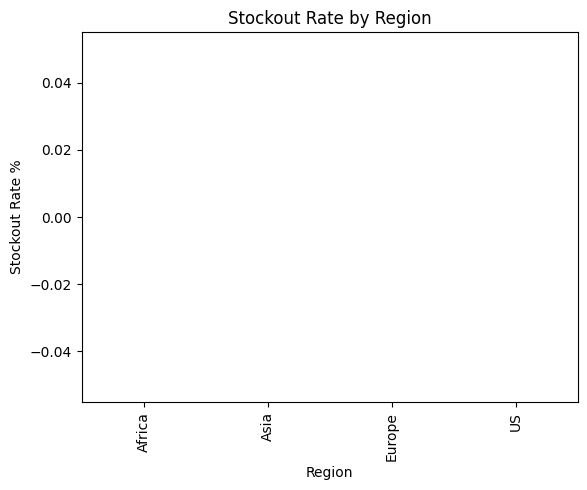

In [22]:
stockout_by_region = df.groupby("Region")["Stockout"].mean() * 100

stockout_by_region.plot(kind="bar")
plt.title("Stockout Rate by Region")
plt.xlabel("Region")
plt.ylabel("Stockout Rate %")
plt.show()

**Correlation Analysis**

In [25]:
numeric_cols = ["Sales", "Profit", "Order_Quantity", "Inventory_Level", "Lead_Time", "Demand", "Stockout"]

corr = df[numeric_cols].corr()

corr

,Sales,Profit,Order_Quantity,Inventory_Level,Lead_Time,Demand,Stockout
Sales,1.000000,-0.000869,-0.000548,0.000416,-0.000660,-0.000799,NaN
Profit,-0.000869,1.000000,0.000416,0.000552,0.000765,0.000190,NaN
Order_Quantity,-0.000548,0.000416,1.000000,-0.000224,-0.000624,0.968195,NaN
Inventory_Level,0.000416,0.000552,-0.000224,1.000000,0.001632,-0.000634,NaN
Lead_Time,-0.000660,0.000765,-0.000624,0.001632,1.000000,-0.001184,NaN
Demand,-0.000799,0.000190,0.968195,-0.000634,-0.001184,1.000000,NaN
Stockout,NaN,NaN,NaN,NaN,NaN,NaN,NaN


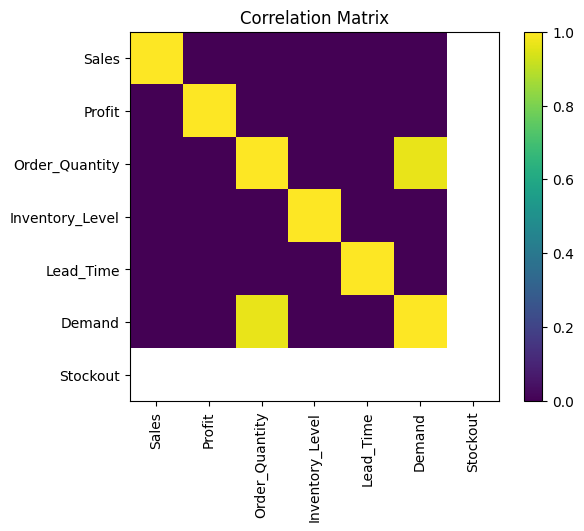

In [26]:
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

## Model 1: Demand Forecasting

In [28]:
features = ["Sales", "Profit", "Order_Quantity", "Inventory_Level", "Lead_Time", "Year", "Month"]
target = "Demand"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

df["Predicted_Demand"] = model.predict(X)


MAE: 1.2533475625000001
RMSE: 1.4536388688499116
R2 Score: 0.9339670993547156


## Model 2: Stockout Prediction

In [31]:
features = ["Sales", "Profit", "Order_Quantity", "Inventory_Level", "Lead_Time", "Demand", "Year", "Month"]
target = "Stockout"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

stockout_pred = clf.predict(X_test)
#for Evaluting
print("Accuracy:", accuracy_score(y_test, stockout_pred))
print(classification_report(y_test, stockout_pred))
#for prediction
df["Predicted_Stockout"] = clf.predict(df[features])

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    200000

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



## Exporting Cleaned Data for Power BI

In [33]:
from google.colab import files
df.to_csv("Cleaned_SupplyChain_For_PowerBI.csv", index=False)
files.download("Cleaned_SupplyChain_For_PowerBI.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>